# Experiment D - Hybrid Model

## 1. Objective 

To evaluate whether combining engineered numerical match-state features with DistilBERT's textual event representations improves football momentum prediction.

## 2. Hypothesis

The engineered numerical match-state features contain complementary information that is not fully captured by the textual event sequence. Therefore, integrating these structured features with DistilBERT's text embeddings will improve momentum prediction performance over the text-only DistilBERT model.

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import sys

BASE_DIR = Path.cwd().parent
sys.path.append(str(BASE_DIR))

from config import *
from helper import *

DATA_PATH = BASE_DIR / "data" / "processed" / EXPERIMENT
MODELS_PATH = BASE_DIR / 'models' / EXPERIMENT
REPORTS_PATH = BASE_DIR / 'reports' / 'metrics' / EXPERIMENT
FIGURE_PATH = BASE_DIR / "reports" / "figures" / EXPERIMENT

## 3. Hybrid Dataset Construction

We would need to merge the train, validation & test datasets for both Experiment A & Experiment C, to create a hybrid dataset for this experiment. We would merging the datasets on match unique id `id_odsp` & `window_start` & then running some validation checks since the datasets of C are a subset of A.

### 3.1 Loading Datasets

In [2]:
# Loading Datasets of Experiment A
train_a = pd.read_csv(BASE_DIR / 'data' / 'processed' / 'exp_a_prefix' / 'train.csv')
val_a = pd.read_csv(BASE_DIR / 'data' / 'processed' / 'exp_a_prefix' / 'val.csv')
test_a = pd.read_csv(BASE_DIR / 'data' / 'processed' / 'exp_a_prefix' / 'test.csv')

In [3]:
# Loading Datasets of Experiment C
train_c =  pd.read_csv(BASE_DIR / 'data' / 'processed' / 'exp_c_tabular' / 'train.csv')
val_c = pd.read_csv(BASE_DIR / 'data' / 'processed' / 'exp_c_tabular' / 'val.csv')
test_c = pd.read_csv(BASE_DIR / 'data' / 'processed' / 'exp_c_tabular' / 'test.csv')

### 3.2 Merging Datasets

In [4]:
# Merge Datasets 
train_d = train_a.merge(
    train_c,
    on=['id_odsp','window_start'],
    how='inner',
    suffixes=('', '_c') 
)

val_d = val_a.merge(
    val_c,
    on=['id_odsp','window_start'],
    how='inner',
    suffixes=('', '_c') 
)

test_d = test_a.merge(
    test_c,
    on=['id_odsp','window_start'],
    how='inner',
    suffixes=('', '_c') 
)


### 3.3 Validating Datasets

In [5]:
# checking join integrity

assert len(train_d) == len(train_a), f"Row count mismatch: {len(train_d)} vs {len(train_a)}"
assert len(val_d) == len(val_a), f"Row count mismatch: {len(val_d)} vs {len(val_a)}"
assert len(test_d) == len(test_a), f"Row count mismatch: {len(test_d)} vs {len(test_a)}"

In [6]:
# Label consistency check

print((train_d['label'] == train_d['label_c']).all())
print((val_d['label'] == val_d['label_c']).all())
print((test_d['label'] == test_d['label_c']).all())

print((train_d['window_end'] == train_d['window_end_c']).all()) 
print((val_d['window_end'] == val_d['window_end_c']).all()) 
print((test_d['window_end'] == test_d['window_end_c']).all()) 

True
True
True
True
True
True


In [7]:
for name, df in {
    "train": train_d,
    "val": val_d,
    "test": test_d
}.items():
    assert not df.duplicated(["id_odsp", "window_start"]).any(), \
        f"{name} contains duplicate keys"

print("No duplicate keys ✓")

No duplicate keys ✓


In [8]:
numeric_cols = [c for c in train_c.columns
                if c not in ["id_odsp","window_start","window_end","label"]]

for name, df in {
    "train": train_d,
    "val": val_d,
    "test": test_d
}.items():
    assert df[numeric_cols].isna().sum().sum() == 0, \
        f"{name} contains NaNs"

print("No missing numeric features ✓")

No missing numeric features ✓


In [9]:
# checking merge coverage 

assert set(zip(train_a.id_odsp, train_a.window_start)) == \
    set(zip(train_d.id_odsp, train_d.window_start))

In [10]:
# Check Duplicate Columns Names
train_d.columns.tolist() 

['id_odsp',
 'window_start',
 'window_end',
 'momentum_score',
 'label',
 'text',
 'text_length',
 'window_end_c',
 'label_c',
 'momentum_lag_1',
 'momentum_lag_2',
 'momentum_lag_3',
 'home_cum_shots',
 'away_cum_shots',
 'home_goals',
 'away_goals',
 'goal_diff',
 'minutes_elapsed',
 'home_cum_shots_on_target',
 'away_cum_shots_on_target',
 'home_cum_shots_inside_box',
 'away_cum_shots_inside_box',
 'home_cum_sub_count',
 'away_cum_sub_count',
 'home_cum_corners',
 'away_cum_corners',
 'home_cum_yellow_cards',
 'away_cum_yellow_cards',
 'home_cum_red_cards',
 'away_cum_red_cards',
 'home_cum_offsides',
 'away_cum_offsides',
 'home_cum_fast_breaks',
 'away_cum_fast_breaks',
 'home_cum_set_piece_shots',
 'away_cum_set_piece_shots',
 'home_minutes_since_last_event',
 'away_minutes_since_last_event']

In [11]:
# Dropping duplicate columns created while merging label_c & window_end_c

for name, df in {"train": train_d, "val": val_d, "test": test_d}.items():
    df.drop(columns=['label_c','window_end_c'], inplace=True)

### 3.4 Saving Processed Datasets



In [12]:
train_d.to_parquet(DATA_PATH / "train.parquet", index=False)
val_d.to_parquet(DATA_PATH / "val.parquet", index=False)
test_d.to_parquet(DATA_PATH / "test.parquet", index=False)

### 3.5 Scaling Numeric Features

In [13]:
from sklearn.preprocessing import StandardScaler
import joblib
import json

DROP_COLS = [
    "id_odsp",
    "window_start",
    "window_end",
    "text",
    "label"
]

numeric_cols = [c for c in train_d.columns if c not in DROP_COLS]

scaler = StandardScaler()
scaler.fit(train_d[numeric_cols])

joblib.dump(scaler, MODELS_PATH / "numeric_scaler.joblib")

with open(MODELS_PATH / "numeric_cols.json", "w") as f:
    json.dump(numeric_cols, f, indent=4)

## 4. Model Training

The hybrid DistilBERT model retained the same training configuration and classification head used in the previous experiments. The only architectural modification was the addition of a lightweight feed-forward projection network that transformed the engineered numerical features into a compact representation. This representation was concatenated with the DistilBERT text embedding before the final classification layer, enabling the model to combine textual event information with structured match-state features.

The model was trained using the combined hybrid training dataset, where each sample consisted of the textual event sequence paired with its corresponding engineered numerical features. Model selection was performed using the combined validation set, and the final performance was evaluated on a held-out combined test set that was not used during training or model selection.

## 5. Training Dynamics

The training and validation curves illustrate the learning behaviour of the hybrid DistilBERT model during training. Corresponding curves from Experiment A are included for comparison to assess the effect of incorporating engineered numerical features.

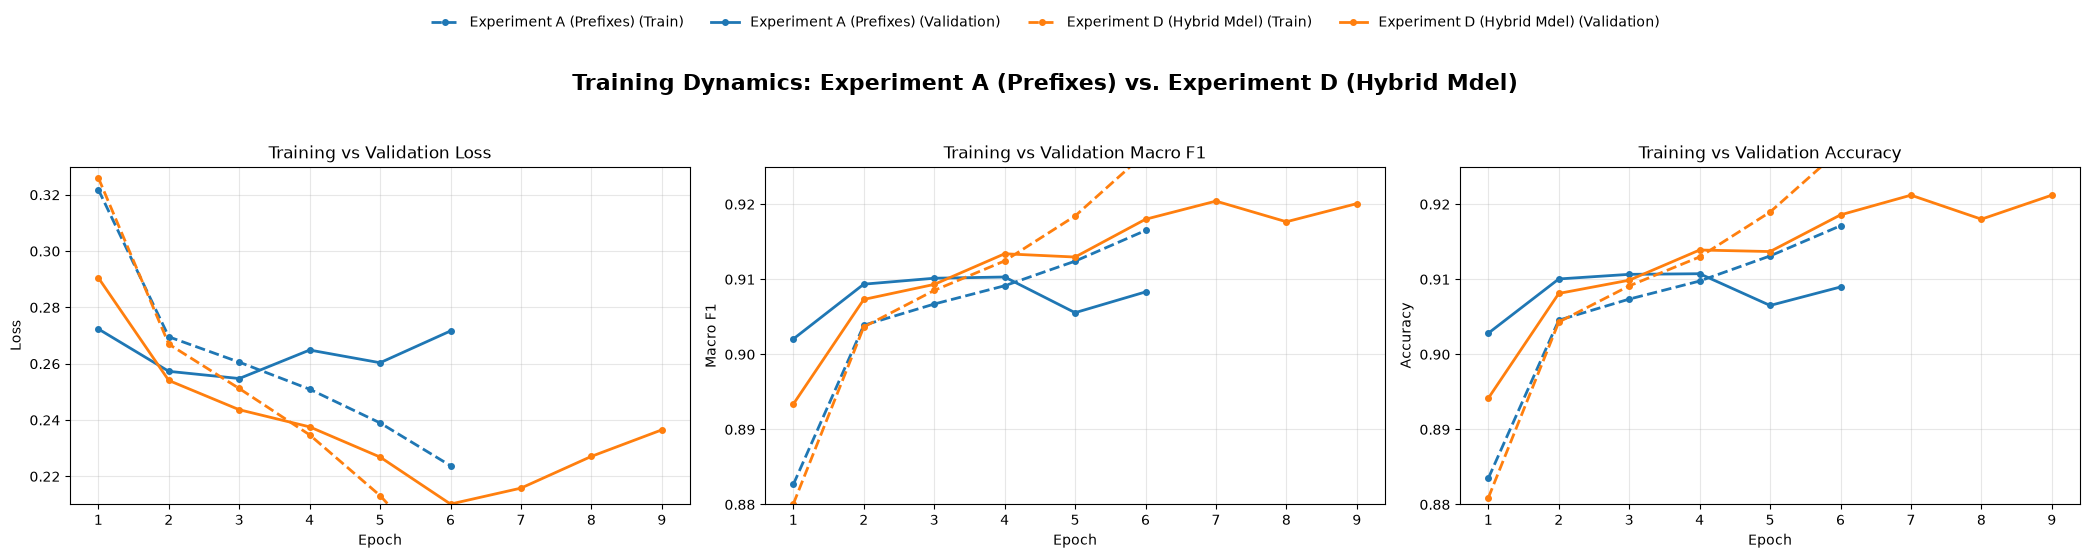

In [18]:
# Load Results
hybrid_results = pd.read_csv(MODELS_PATH / 'bert_hybrid_momentum_results.csv') 
exp_a_results = pd.read_csv(BASE_DIR / 'models'/ 'exp_a_prefix' / 'distilbert_results.csv')

# Plot Curves
fig, axes = plot_model_comparison(
    model1_history=exp_a_results,
    model1_name="Experiment A (Prefixes)",
    model2_history=hybrid_results,
    model2_name="Experiment D (Hybrid Mdel)",
    save_dir=FIGURE_PATH,
    filename="hybrid_comparison_curves.png",
    loss_ylim=(0.21, 0.33),
    f1_ylim=(0.88, 0.925),
    accuracy_ylim=(0.88, 0.925),
)


### Key Observations: 

- Both models converge rapidly. The majority of the performance gain occurs within the first few epochs, indicating that the pre-trained DistilBERT encoder adapts quickly to the football momentum forecasting task.

- The hybrid model consistently outperforms Experiment A throughout training. From approximately the second epoch onward, the hybrid model achieves lower validation loss and higher validation Macro F1 and accuracy than the text-only baseline, suggesting that the engineered numerical features provide useful complementary information during learning.

- Validation loss decreases further before early stopping. The hybrid model continues reducing validation loss beyond the point reached by Experiment A, indicating that the additional numerical features improve the model's ability to generalize rather than simply accelerating optimization.

- The hybrid model exhibits a slightly stronger tendency to overfit. Training performance continues to improve after the validation metrics begin to plateau, but early stopping successfully identifies the optimal checkpoint before noticeable degradation in generalization occurs.

- The training behaviour remains stable. Despite the introduction of an additional numerical feature branch, the optimization process remains smooth with no signs of unstable convergence or oscillating validation performance.

## 6. Experimental Results

### 6.1 Classification Report

In [20]:
from IPython.display import Markdown, display

with open(REPORTS_PATH / 'bert_hybrid_momentum.txt', 'r') as f:
    hybrid_report = f.read()

display(Markdown('### Experiment D - Hybrid Model'))
print(hybrid_report)

### Experiment D - Hybrid Model

 Hybrid DistilBERT - Test Set Evaluation
               precision    recall  f1-score   support

Home Dominant       0.95      0.93      0.94      9492
Away Dominant       0.93      0.93      0.93      7095
     Balanced       0.87      0.90      0.88      7870

     accuracy                           0.92     24457
    macro avg       0.92      0.92      0.92     24457
 weighted avg       0.92      0.92      0.92     24457



### 6.2 Confusion Matrix Comparison

The normalized confusion matrices compare the class-wise prediction behaviour of the text-only baseline (Experiment A) and the proposed hybrid model (Experiment D). For reference, the corresponding confusion matrices containing absolute prediction counts are also provided below.

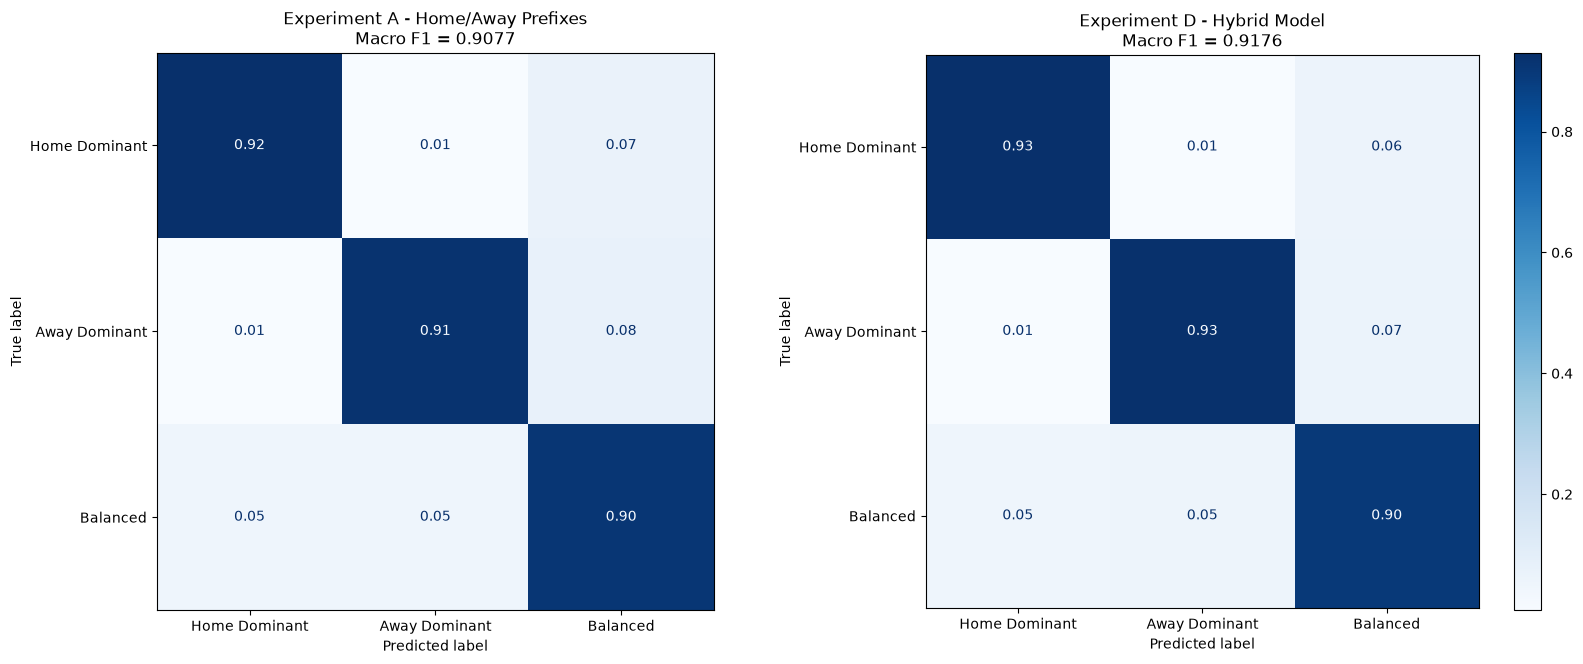

In [29]:
# Load preds & labels

# Experiment A
exp_a_preds = np.load(BASE_DIR / 'reports' / 'metrics' / 'exp_a_prefix' / 'bert_momentum_preds.npy')
exp_a_labels = np.load(BASE_DIR / 'reports' / 'metrics' / 'exp_a_prefix' / 'bert_momentum_labels.npy')

# Hybrid
hybrid_preds = np.load(REPORTS_PATH/'bert_hybrid_momentum_preds.npy')
hybrid_labels = np.load(REPORTS_PATH/'bert_hybrid_momentum_labels.npy')

plot_confusion_matrices(
    model1_true=exp_a_labels,
    model1_preds=exp_a_preds,
    model2_true=hybrid_labels,
    model2_preds=hybrid_preds,
    display_labels=CLASS_NAMES,
    model1_name="Experiment A - Home/Away Prefixes",
    model2_name="Experiment D - Hybrid Model",
    save_dir=FIGURE_PATH,
    filename="hybrid_comparison_cm.png",
)

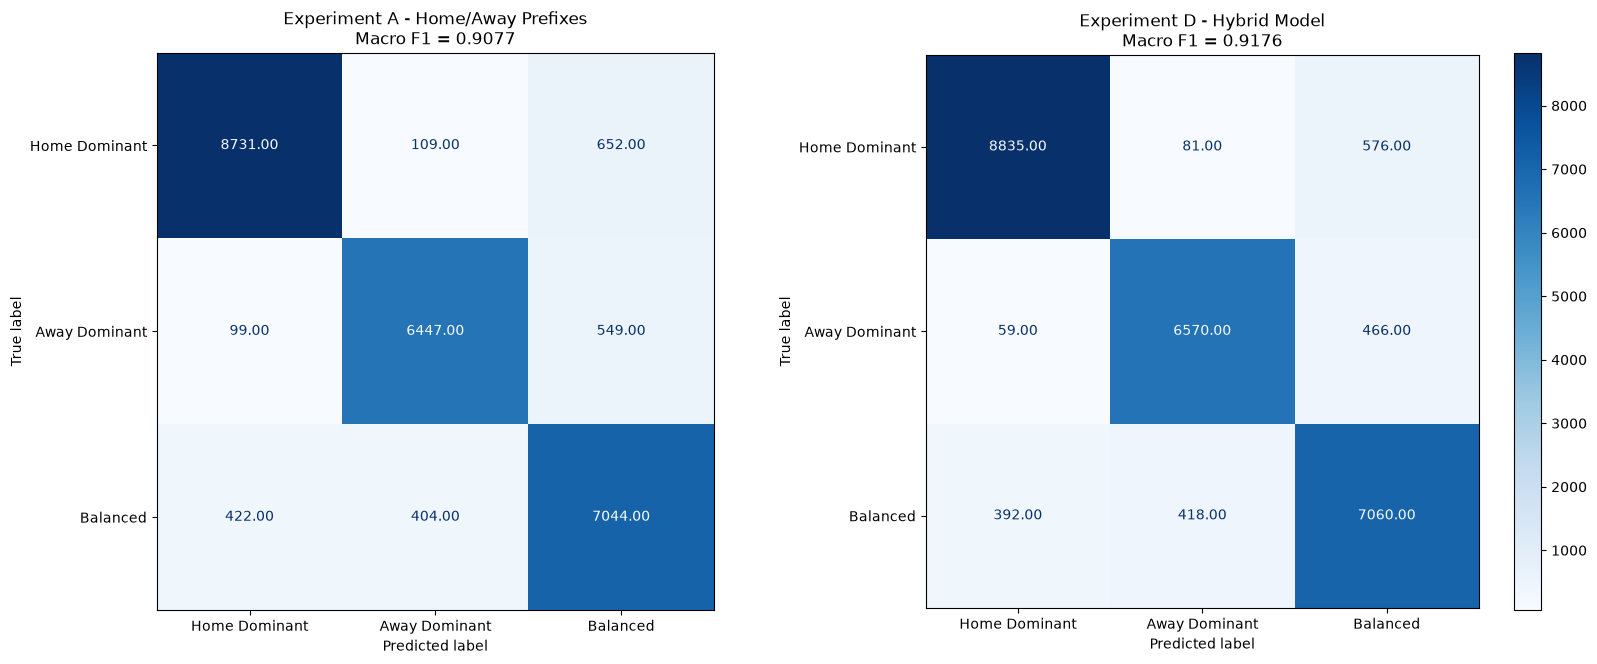

In [28]:
plot_confusion_matrices(
    model1_true=exp_a_labels,
    model1_preds=exp_a_preds,
    model2_true=hybrid_labels,
    model2_preds=hybrid_preds,
    display_labels=CLASS_NAMES,
    model1_name="Experiment A - Home/Away Prefixes",
    model2_name="Experiment D - Hybrid Model",
    normalize=None,
    save_dir=FIGURE_PATH,
    filename="hybrid_actual_counts_cm.png",
)

### 6.3 Comparison with Experiment A

In [ ]:
report_a = load_report(BASE_DIR / 'reports' /'metrics' / 'exp_a_prefix' /"bert_momentum_metrics.txt")
report_d = load_report(REPORTS_PATH / "bert_hybrid_momentum_metrics.txt")

summary = compare_classification_reports(
    report_a,
    report_d,
    names=("Experiment A - Prefix", "Experiment D - Hybrid Model")
)

display(
    summary.style
    .format({
        "Experiment A - Prefix": "{:.4f}",
        "Experiment D - Hybrid Model": "{:.4f}",
        "Δ": "{:+.4f}",
    })
    .background_gradient(subset=["Δ"], cmap="RdYlGn")
    .hide(axis="index")
)

Metric,Experiment A - Prefix,Experiment D - Hybrid Model,Δ
Accuracy,0.9086,0.9186,+0.0099
Macro Precision,0.9081,0.9174,+0.0093
Macro Recall,0.9078,0.9180,+0.0101
Macro F1,0.9077,0.9176,+0.0098
Weighted F1,0.9090,0.9188,+0.0098
Home Dominant F1,0.9316,0.9410,+0.0094
Away Dominant F1,0.9174,0.9277,+0.0103
Balanced F1,0.8742,0.8840,+0.0098


### 6.4 Key Observations

- The hybrid DistilBERT model outperformed the text-only baseline across all aggregate evaluation metrics, including accuracy, Macro Precision, Macro Recall, Macro F1, and Weighted F1.

- Per-class performance improved for all three momentum classes, indicating that the performance gain was not driven by a single class.

- The confusion matrices indicate that the hybrid model reduces misclassifications for all three momentum classes. The most noticeable improvements occur for the Home Dominant and Away Dominant classes, while the Balanced class also benefits from a smaller but consistent increase in classification performance.

- Although the improvement over Experiment A was modest (approximately one percentage point in Macro F1), it was consistent across multiple evaluation metrics and on the held-out test set.

## 7. Discussion 

Experiment D investigated whether engineered numerical match-state features could provide complementary information beyond textual event sequence learned by DistilBERT. The hybrid model achieved consistent improvements across all aggregate evaluation metrics and all three momentum classes on held-out set, indicating that the structured numerical features contributed additional predictive information beyond the text-only representation.

An important observation is that these findings do not contradict Experiment C. The engineered numerical features performed poorly when used in isolation, demonstrating that they were insufficient to model football momentum on their own. However, when combined with textual event descriptions, the same features consistently improved the DistilBERT baseline. This suggests that the numerical features contain complementary information rather than a complete representation of momentum.

The magnitude of the improvement remained relatively modest, approximately one percentage point in Macro F1. This indicates that the textual event sequence already captures the majority of the predictive signal, leaving comparatively little additional information for the structured numerical features to contribute. Nevertheless, the consistent improvement across multiple evaluation metrics suggests that the additional features provide useful contextual information rather than merely increasing model complexity.

The numerical branch consisted of a lightweight projection network containing only a single linear layer followed by GELU activation and dropout. Despite its simplicity, the hybrid architecture improved performance over the text-only baseline. This suggests that the observed improvement is primarily attributable to the complementary information contained within the engineered features rather than to a substantial increase in model capacity.

As with the previous experiments, these findings are based on a single training run per model and were not validated across multiple random seeds. Consequently, although the improvement was consistently observed on the held-out test set, additional repeated-seed experiments would be required to quantify the variability of the observed performance gain and assess its statistical robustness.

## 8. Conclusion

Experiment D evaluated whether engineered numerical match-state features could improve football momentum forecasting when combined with DistilBERT. The hybrid model consistently outperformed the text-only baseline across all aggregate evaluation metrics and individual momentum classes on the held-out test set. Although the performance improvement was modest, it was observed using a lightweight fusion architecture while keeping the remainder of the model unchanged. These findings support the hypothesis that structured numerical match-state features provide complementary information to textual event descriptions, even though the same features were insufficient for accurate momentum prediction when used independently in Experiment C.

Overall, the results demonstrate that combining sequential textual event descriptions with structured match-state information provides a more complete representation of football momentum than either modality alone.